# TEMPO Performance Testing:
## Wall-Clock Timing for Rabi Oscillations

## Configuration
Set all sweep parameters and test configuration here

In [1]:
# ============================================
# TEST CONFIGURATION
# ============================================

# Number of repetitions for each configuration (for averaging)
NUM_REPETITIONS = 6

# Parameter sweeps
NUM_PULSES = [2, 3, 5, 10]  # Number of pulses in sequence
DURATION_MULTIPLIERS = [1, 2, 3, 4, 5]  # Multipliers for base duration
BASE_DURATION = 0.5  # Base pulse sequence duration in microseconds

AMPLITUDE_VALUES = [5, 10, 15, 20]  # Pulse amplitude values to test

# Time evaluation points
NUM_TIME_POINTS = 100  # Number of time points for state evaluation

# Evolution methods to compare
EVOLUTION_METHODS = ['regular', 'serial', 'serial_safe']

print("Configuration loaded:")
print(f"  Repetitions per config: {NUM_REPETITIONS}")
print(f"  Number of pulses: {NUM_PULSES}")
print(f"  Duration range: {BASE_DURATION * min(DURATION_MULTIPLIERS)} - {BASE_DURATION * max(DURATION_MULTIPLIERS)} μs")
print(f"  Amplitude values: {AMPLITUDE_VALUES}")
print(f"  Evolution methods: {EVOLUTION_METHODS}")

Configuration loaded:
  Repetitions per config: 6
  Number of pulses: [2, 3, 5, 10]
  Duration range: 0.5 - 2.5 μs
  Amplitude values: [5, 10, 15, 20]
  Evolution methods: ['regular', 'serial', 'serial_safe']


## Import Packages

In [22]:
# Standard library imports
import sys
import time
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.font_manager as font_manager
from collections import defaultdict
import seaborn as sns
from scipy.optimize import curve_fit

# QuTiP imports
from qutip import *

In [23]:
# TEMPO imports
from tempo.hamiltonian import Hamiltonian
from tempo.pulse_recipe import Pulse_recipe
from tempo.evolver import Evolver
from tempo.pulse_sequence import Pulse_sequence
from tempo.pulse import Pulse

print("All packages imported successfully!")

All packages imported successfully!


## Step 1: Define 2-Level System
Create the static Hamiltonian and pulse recipe for Rabi oscillations

In [4]:
# Parameters for static Hamiltonian (2-level system)
E0 = 1000  # Energy splitting in MHz
pars_Hsz = {'coeff': -2*np.pi, 'E': E0}
ops_Hsz = {'SZ': sigmaz()}

# Define function for static Hamiltonian
def f_Hsz(ops, pars):
    sz = ops['SZ']
    c = pars['coeff']
    E = pars['E']
    return c * E * sz

# Create static Hamiltonian
Hs = Hamiltonian(ops_Hsz, pars_Hsz, f_Hsz)
Hs_op = Hs.H

# Calculate eigenenergies and transition frequency
eig_energies = Hs_op.eigenenergies() / (2 * np.pi)
frq_trans = max(eig_energies) - min(eig_energies)

print(f"Static Hamiltonian created")
print(f"  Eigenenergies: {eig_energies} MHz")
print(f"  Transition frequency: {frq_trans} MHz")

Static Hamiltonian created
  Eigenenergies: [-1000.  1000.] MHz
  Transition frequency: 1999.9999999999998 MHz


In [5]:
# Define the time-dependent pulse function
# Form: A*cos(omega*t)
def func_X(t, args):
    return args['AMP'] * np.cos(2 * np.pi * args['FREQ'] * t)

# Operator to be multiplied by function output
H_X = 2 * np.pi * sigmax()

# Parameter names for pulse recipe
keys_X = ['AMP', 'FREQ']

# Create the pulse recipe (blueprint for any pulse)
recipe_X = Pulse_recipe(Hamiltonian(H_X), keys_X, func_X)

print("Pulse recipe created")
print(f"  Parameters: {keys_X}")

Pulse recipe created
  Parameters: ['AMP', 'FREQ']


In [7]:
# Define initial state (ground state |0⟩)
state_init = basis(2, 0)

# Define options for mesolve (as dict, not Options class)
opts = {'nsteps': 10_000, 'atol': 1e-6, 'rtol': 1e-6}

print("Initial state and solver options configured")
print(f"  Initial state: |0⟩")
print(f"  Solver options: nsteps={opts['nsteps']}, atol={opts['atol']}, rtol={opts['rtol']}")

Initial state and solver options configured
  Initial state: |0⟩
  Solver options: nsteps=10000, atol=1e-06, rtol=1e-06


## Step 2: Run Timing Tests
Sweep through parameters and measure wall-clock time for each configuration

In [9]:
def create_pulse_sequence(num_pulses, total_duration, amplitude):
    """
    Create a pulse sequence with specified parameters.
    
    Parameters:
    -----------
    num_pulses : int
        Number of pulses in the sequence
    total_duration : float
        Total duration of the pulse sequence in microseconds
    amplitude : float
        Amplitude of the pulses
        
    Returns:
    --------
    Pulse_sequence object
    """
    # Create pulse sequence
    ps = Pulse_sequence(Hstat=Hs_op)
    
    # Duration of each pulse
    dt = total_duration / num_pulses
    
    # Create pulses and add them to the sequence
    for i in range(num_pulses):
        start_time = i * dt
        
        # Last pulse might need adjustment to reach exact total_duration
        if i == num_pulses - 1:
            duration = total_duration - start_time
        else:
            duration = dt
        
        # Parameter values for this pulse
        par_values = {'AMP': amplitude, 'FREQ': frq_trans}
        
        # Create and add pulse
        pulse = Pulse(recipe_X, 
                     start_time=start_time, 
                     duration=duration, 
                     coeff_params=par_values)
        ps.add_pulse(pulse)
    
    return ps

print("Pulse sequence creation function defined")

Pulse sequence creation function defined


In [10]:
# ============================================
# MAIN TIMING LOOP
# ============================================

print("Starting timing tests...")
print(f"Total configurations to test: {len(NUM_PULSES)} pulses × {len(DURATION_MULTIPLIERS)} durations × {len(AMPLITUDE_VALUES)} amplitudes")
print(f"Each configuration will be run {NUM_REPETITIONS} times for each of {len(EVOLUTION_METHODS)} methods")
print(f"Estimated total runs: {len(NUM_PULSES) * len(DURATION_MULTIPLIERS) * len(AMPLITUDE_VALUES) * NUM_REPETITIONS * len(EVOLUTION_METHODS)}")
print("-" * 60)

# Data structure to store timing results
# Format: timing_results[method][n_pulses][duration][amplitude] = [list of times]
timing_results = {method: defaultdict(lambda: defaultdict(lambda: defaultdict(list))) 
                  for method in EVOLUTION_METHODS}

# Start overall timer
overall_start = time.time()

# Counter for progress
config_count = 0
total_configs = len(NUM_PULSES) * len(DURATION_MULTIPLIERS) * len(AMPLITUDE_VALUES)

# Loop through all parameter combinations
for n_pulses in NUM_PULSES:
    for duration_mult in DURATION_MULTIPLIERS:
        total_duration = BASE_DURATION * duration_mult
        
        for amplitude in AMPLITUDE_VALUES:
            config_count += 1
            print(f"\n[{config_count}/{total_configs}] Testing: {n_pulses} pulses, {total_duration} μs, amp={amplitude}")
            
            # Create pulse sequence for this configuration
            ps = create_pulse_sequence(n_pulses, total_duration, amplitude)
            
            # Create time evaluation array
            arr_times = np.linspace(0, total_duration, NUM_TIME_POINTS)
            
            # Create evolver object
            ev = Evolver(state_init, arr_times, ps, opts=opts)
            
            # Test each evolution method
            for method in EVOLUTION_METHODS:
                method_times = []
                
                # Run multiple repetitions
                for rep in range(NUM_REPETITIONS):
                    start = time.time()
                    result = ev.evolve(method=method)
                    end = time.time()
                    elapsed = end - start
                    method_times.append(elapsed)
                
                # Store results
                timing_results[method][n_pulses][total_duration][amplitude] = method_times
                
                # Print summary for this method
                avg_time = np.mean(method_times)
                std_time = np.std(method_times)
                print(f"  {method:12s}: {avg_time:.4f} ± {std_time:.4f} s")

overall_end = time.time()
total_time = overall_end - overall_start

print("\n" + "=" * 60)
print(f"TIMING TESTS COMPLETE!")
print(f"Total time: {total_time/60:.2f} minutes")
print("=" * 60)

Starting timing tests...
Total configurations to test: 4 pulses × 5 durations × 4 amplitudes
Each configuration will be run 6 times for each of 3 methods
Estimated total runs: 1440
------------------------------------------------------------

[1/80] Testing: 2 pulses, 0.5 μs, amp=5
  regular     : 0.0600 ± 0.0158 s
  serial      : 0.0378 ± 0.0004 s
  serial_safe : 0.0479 ± 0.0003 s

[2/80] Testing: 2 pulses, 0.5 μs, amp=10
  regular     : 0.0578 ± 0.0003 s
  serial      : 0.0416 ± 0.0003 s
  serial_safe : 0.0450 ± 0.0001 s

[3/80] Testing: 2 pulses, 0.5 μs, amp=15
  regular     : 0.1028 ± 0.0004 s
  serial      : 0.0619 ± 0.0010 s
  serial_safe : 0.0670 ± 0.0010 s

[4/80] Testing: 2 pulses, 0.5 μs, amp=20
  regular     : 0.1097 ± 0.0023 s
  serial      : 0.0804 ± 0.0021 s
  serial_safe : 0.0892 ± 0.0018 s

[5/80] Testing: 2 pulses, 1.0 μs, amp=5


/Users/jjoon/anaconda3/lib/python3.12/site-packages/qutip/solver/solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


  regular     : 0.1030 ± 0.0005 s
  serial      : 0.0783 ± 0.0033 s
  serial_safe : 0.0840 ± 0.0018 s

[6/80] Testing: 2 pulses, 1.0 μs, amp=10
  regular     : 0.1128 ± 0.0007 s
  serial      : 0.0817 ± 0.0004 s
  serial_safe : 0.0889 ± 0.0007 s

[7/80] Testing: 2 pulses, 1.0 μs, amp=15
  regular     : 0.2096 ± 0.0032 s
  serial      : 0.1506 ± 0.0022 s
  serial_safe : 0.1663 ± 0.0010 s

[8/80] Testing: 2 pulses, 1.0 μs, amp=20
  regular     : 0.2209 ± 0.0010 s
  serial      : 0.1609 ± 0.0029 s
  serial_safe : 0.1803 ± 0.0028 s

[9/80] Testing: 2 pulses, 1.5 μs, amp=5
  regular     : 0.1606 ± 0.0033 s
  serial      : 0.1196 ± 0.0004 s
  serial_safe : 0.1287 ± 0.0002 s

[10/80] Testing: 2 pulses, 1.5 μs, amp=10
  regular     : 0.1767 ± 0.0005 s
  serial      : 0.1285 ± 0.0015 s
  serial_safe : 0.1377 ± 0.0006 s

[11/80] Testing: 2 pulses, 1.5 μs, amp=15
  regular     : 0.3203 ± 0.0028 s
  serial      : 0.1862 ± 0.0015 s
  serial_safe : 0.2054 ± 0.0028 s

[12/80] Testing: 2 pulses, 1.5 μ

## Step 3: Process and Analyze Results
Calculate averages and organize data for visualization

In [12]:
# ============================================
# CALCULATE STATISTICS
# ============================================

# Data structure for processed results
# Format: processed_results[method][n_pulses][duration][amplitude] = {'mean': X, 'std': Y, 'min': Z, 'max': W}
processed_results = {method: defaultdict(lambda: defaultdict(lambda: defaultdict(dict))) 
                     for method in EVOLUTION_METHODS}

for method in EVOLUTION_METHODS:
    for n_pulses in NUM_PULSES:
        for duration_mult in DURATION_MULTIPLIERS:
            total_duration = BASE_DURATION * duration_mult
            for amplitude in AMPLITUDE_VALUES:
                times = timing_results[method][n_pulses][total_duration][amplitude]
                
                processed_results[method][n_pulses][total_duration][amplitude] = {
                    'mean': np.mean(times),
                    'std': np.std(times),
                    'min': np.min(times),
                    'max': np.max(times),
                    'raw': times
                }

print("Statistics calculated for all configurations")
print(f"  Methods: {EVOLUTION_METHODS}")
print(f"  Pulse counts: {NUM_PULSES}")
print(f"  Durations: {[BASE_DURATION * m for m in DURATION_MULTIPLIERS]} μs")
print(f"  Amplitudes: {AMPLITUDE_VALUES}")

Statistics calculated for all configurations
  Methods: ['regular', 'serial', 'serial_safe']
  Pulse counts: [2, 3, 5, 10]
  Durations: [0.5, 1.0, 1.5, 2.0, 2.5] μs
  Amplitudes: [5, 10, 15, 20]


## Step 4: Visualize Results
Plot timing comparisons across different parameters

In [20]:
# Plot styling configuration
cm = 1/2.54  # centimeters to inches
matplotlib.rc('font', family='Helvetica')
font1 = dict(fontname="Helvetica", weight="normal", fontsize=9)
font = font_manager.FontProperties(family='Helvetica', weight='normal', style='normal', size=9)

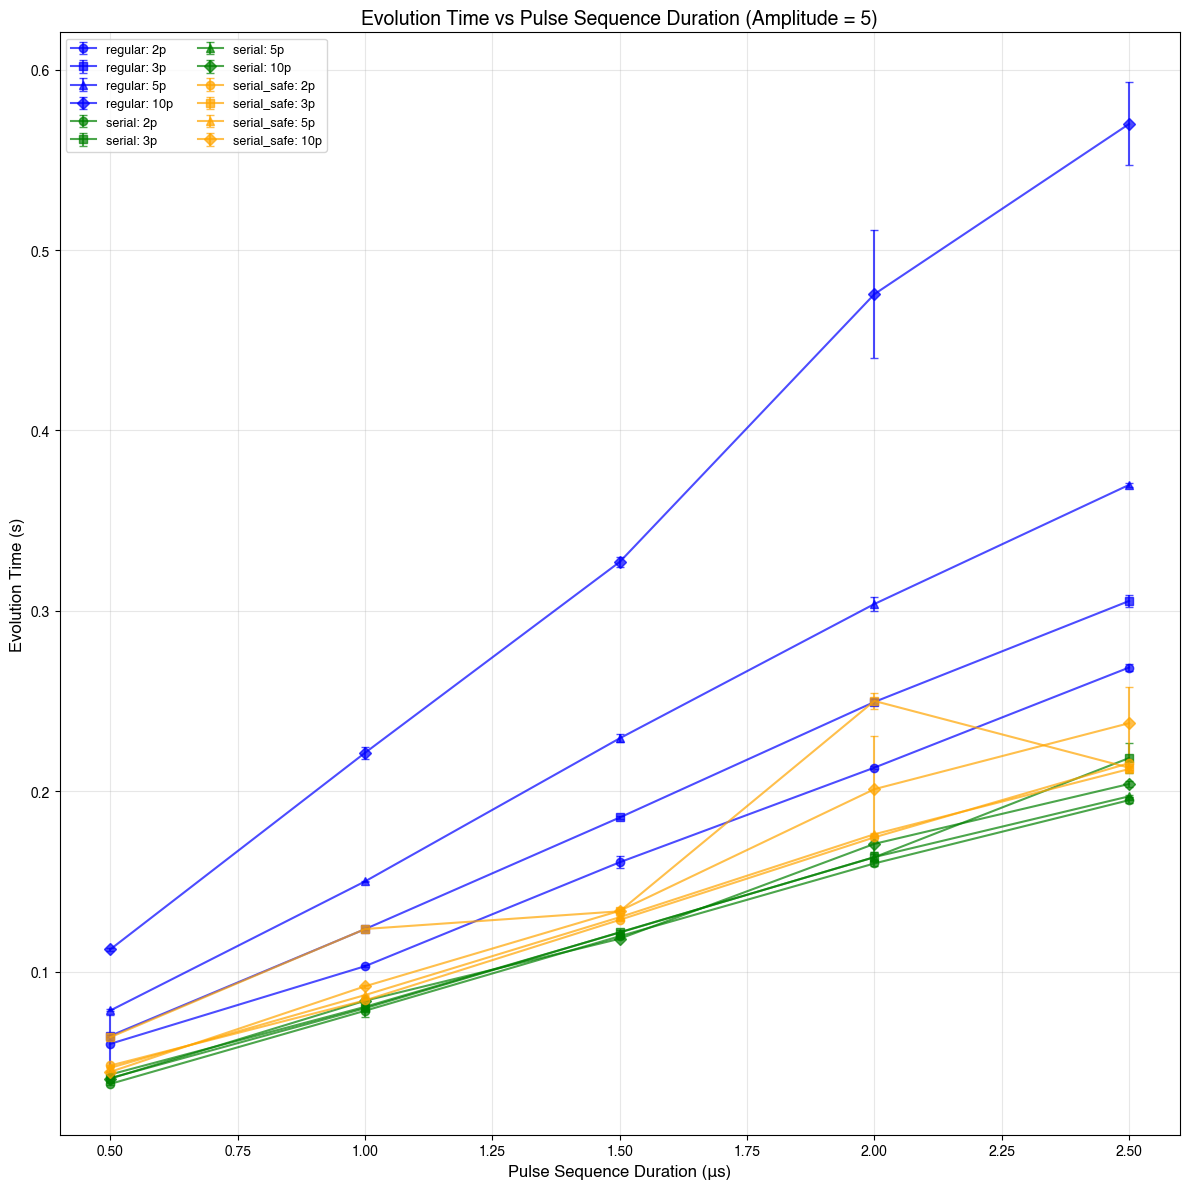

In [21]:
# ============================================
# PLOT 1: Evolution Time vs Duration
# ============================================

# Use a fixed amplitude for this plot
plot_amplitude = AMPLITUDE_VALUES[0]

fig, ax = plt.subplots(figsize=(12, 12))

colors = {'regular': 'blue', 'serial': 'green', 'serial_safe': 'orange'}
markers = {2: 'o', 3: 's', 5: '^', 10: 'D'}

for method in EVOLUTION_METHODS:
    for n_pulses in NUM_PULSES:
        durations = []
        mean_times = []
        std_times = []
        
        for duration_mult in DURATION_MULTIPLIERS:
            total_duration = BASE_DURATION * duration_mult
            stats = processed_results[method][n_pulses][total_duration][plot_amplitude]
            
            durations.append(total_duration)
            mean_times.append(stats['mean'])
            std_times.append(stats['std'])
        
        # Plot with error bars
        label = f"{method}: {n_pulses}p"
        ax.errorbar(durations, mean_times, yerr=std_times, 
                   label=label, marker=markers[n_pulses], 
                   color=colors[method], alpha=0.7, capsize=3)

ax.set_xlabel('Pulse Sequence Duration (μs)', fontsize=12)
ax.set_ylabel('Evolution Time (s)', fontsize=12)
ax.set_title(f'Evolution Time vs Pulse Sequence Duration (Amplitude = {plot_amplitude})', fontsize=14)
ax.legend(loc='upper left', ncol=2, fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()